In [1]:
import numpy as np
from scipy.special import jv, jvp, jn_zeros, jnp_zeros
from scipy.integrate import tplquad, dblquad, quad
from numpy import pi
import matplotlib.pyplot as plt

## Set variables , modes , effective current J(r)

In [2]:
# Physical constants (set to 1 for dimensionless calculations)
epsilon0 = 1.0
mu0 = 1.0
c = 1.0 / np.sqrt(epsilon0 * mu0)   # speed of light, used to compute ω

eps = 1e-20

# Cavity volume and variables
a_raw = 0.419/2     #m
d_raw = 1.014
B_raw = 7.6     #T
ro_dm_raw = 0.45    #GeV/cc


#NU (GeV)
ro_dm = ro_dm_raw * 1/(1.3e41)
B = B_raw * 1.96e-16
Beta = 1
Q = 45000
a = a_raw * 5.0677e15
d = d_raw * 5.0677e15
V = np.pi * a**2 * d 

e_m = 4e-19


# Ranges for n, p, q (adjust as needed)
n_max = 0
p_max = 1
q_max = 1

# TE MODES COMPUTATION

In [3]:
resultsTE = []

# Loop over all combinations
for n in range(0, n_max+1):
    for p in range(1, p_max+1):
        for q in range(1, q_max+1):
            mode_str = f"{n}{p}{q}"
            #print(f"Computing TE mode {mode_str}...")  optional progress indicator

            try:
                # Wavenumbers
                rootsp = jnp_zeros(n, p)
                kc = rootsp[-1] / a    # kc = Xnp' / a
                kz = q * np.pi / d
                omega = c * np.sqrt(kc**2 + kz**2)# resonant angular frequency
                mass = 2*omega 
                mass_eV = mass*1e09
                def J(r):
                    return  r / a

# First we define the radial component of the modes and their volum integral            
                def E_TE_r_rad (r):
                    if n == 0 or q == 0:
                        return 0.0
                    return  (omega * mu0 / kc**2) * jv(n, kc * r) * n / r

                def E_TE_r_rad_int (r):
                    return E_TE_r_rad(r) * r

                def E_TE_r_rad_int2 (r):
                    return E_TE_r_rad(r)**2 * r

                
                def E_TE_theta_rad (r):
                    if q == 0:
                        return 0.0
                    return  (omega * mu0 / kc ) * jvp(n, kc * r, 1) 

                def E_TE_theta_rad_int (r):
                    return E_TE_theta_rad(r) * r

                def E_TE_theta_rad_int2 (r):
                    return E_TE_theta_rad(r)**2 * r

                
                def H_TE_r_rad (r):
                    if q == 0:
                        return 0.0
                    return (kz / kc) * jvp(n, kc * r, 1)

                def H_TE_r_rad_int (r):
                    return H_TE_r_rad(r) * r

                def H_TE_r_rad_int2 (r):
                    return H_TE_r_rad(r)**2 * r

                
                def H_TE_theta_rad (r):
                    return ( kz / kc**2) * (n / r) * jv(n, kc * r)

                def H_TE_theta_rad_int (r):
                    return H_TE_theta_rad(r) * r

                def H_TE_theta_rad_int2 (r):
                    return H_TE_theta_rad(r)**2 * r

                
                def H_TE_z_rad (r):
                    if q == 0:
                        return 0.0
                    return jv(n, kc * r)

                def H_TE_z_rad_int (r):
                    return H_TE_z_rad(r) * r

                def H_TE_z_rad_int2 (r):
                    return H_TE_z_rad(r)**2 * r

                    
                def Theta_comp_integrated(n):  # sin(nθ) or cos(nθ) , cos(nθ) or -sin(nθ)
                    if n == 0:
                        return 2*np.pi
                    return 0.0

                def Theta_comp_squared_integrated(n): # sin(nθ) or cos(nθ) squared
                    if n == 0:
                        return 2*np.pi
                    return np.pi

                
                def Z_comp_g1_integrated(q):  # cos(qpi/d)  g1: E_z, H_r, H_theta
                    if q == 0:
                        return d
                    return 0.0
                    
                def Z_comp_g2_integrated(q):  # sin(qpi/d)  g2: E_r, E_theta , H_z
                    if q == 0:
                        return 0.0
                    return d/(q*np.pi) * (1-(-1)**q)


                def Z_comp_g1_squared_integrated(q):  #  g1: E_z, H_r, H_theta
                    if q == 0:
                        return d
                    return d/2

                def Z_comp_g2_squared_integrated(q):  #  g2: E_z, H_r, H_theta
                    if q == 0:
                        return 0.0
                    return d/2


                int_E_r, _ = quad(E_TE_r_rad_int, 0, a)
                int_E_theta, _ = quad(E_TE_theta_rad_int, 0, a)
                int_H_r, _ = quad(H_TE_r_rad_int, 0, a)
                int_H_theta, _ = quad(H_TE_theta_rad_int, 0, a)
                int_H_z, _ = quad(H_TE_z_rad_int, 0, a)


                int_E_r2, _ = quad(E_TE_r_rad_int2, 0, a)
                int_E_theta2, _ = quad(E_TE_theta_rad_int2, 0, a)
                int_H_r2, _ = quad(H_TE_r_rad_int2, 0, a)
                int_H_theta2, _ = quad(H_TE_theta_rad_int2, 0, a)
                int_H_z2, _ = quad(H_TE_z_rad_int2, 0, a)

                def integrand_overlap(r):    
                        return E_TE_theta_rad(r) * J(r) * r

                numerator_integral, _ = quad(integrand_overlap, 0, a)

                E2_den = (int_E_r2 * Theta_comp_squared_integrated(n) * Z_comp_g2_squared_integrated(q) +
                        int_E_theta2 * Theta_comp_squared_integrated(n) * Z_comp_g2_squared_integrated(q)) 

                H2_den = (int_H_r2 * Theta_comp_squared_integrated(n) * Z_comp_g1_squared_integrated(q) +
                          int_H_theta2 * Theta_comp_squared_integrated(n) * Z_comp_g1_squared_integrated(q) +
                        int_H_z2 * Theta_comp_squared_integrated(n) * Z_comp_g2_squared_integrated(q))
#Compute the power
                #P = (B/1+B) e^4 B^2 Q a^2 p^2 1/8m^5 V C
                
                if E2_den != 0:
                    C = (numerator_integral * Theta_comp_integrated(n) * Z_comp_g2_integrated(q) )**2 / (E2_den * V)

                    P_mc = (Beta/(1+Beta)) * B**2 * Q * a**2 * V * C * 1/(8*mass**5) * ro_dm**2 / 4.11e-15

                    P_W = P_mc * e_m**4
                    
                   
                    
                else:
                    C = np.nan
                    P_W = np.nan
                
# COMPUTE THE STORED ENERGY  e= e/2 [overlap * E]2 dV
                            #m= mu/2 [overlap * H]2 dV
                
                E2_stored = epsilon0/2 * (numerator_integral * Theta_comp_integrated(n) * Z_comp_g2_integrated(q) )**2 /E2_den 

                H2_stored = mu0/2 * (numerator_integral * Theta_comp_integrated(n) * Z_comp_g2_integrated(q))**2/E2_den**2 * H2_den

                check1 = E2_den/H2_den

                check2 = E2_stored/H2_stored

                omega_MHz = omega * 2.41799e17

                
 # Store results with polarization info
                resultsTE.append((n, p, q, omega_MHz, mass_eV, C, P_W, P_mc))
                
            except Exception as e:
                print(f"  Error for mode {mode_str}: {e}")
                resultsTE.append((n, p, q, omega_MHz, mass_eV, C, P_W, P_mc))

# Print table
print("\n" + "="*110)
print(f"{'n':<2} {'p':<2} {'q':<2} {'omega (MHz)':<15} {'mass (eV)':<15} {'C':<15} {'Power(W)':<15} {'Power(W)·e_m^4':<15} {'Mode':<2}")
print("="*110)
for n, p, q, w, m, c, PW, Pe in resultsTE:
    #check = (epsilon0 * e2) / (mu0 * h2) if (h2 != 0 and not np.isnan(h2)) else np.nan
    print(f"{n:<2} {p:<2} {q:<2} {w:<15.6e} {m:<15.6e} {c:<15.6e} {PW:<15.6e} {Pe:<15.6e} {n:<2} {p:<2} {q:<2}")
print("="*110)


n  p  q  omega (MHz)     mass (eV)       C               Power(W)        Power(W)·e_m^4  Mode
0  1  1  8.851056e+02    7.321003e-06    2.208340e-01    1.003136e-22    3.918499e+51    0  1  1 


C:\Users\usuario\AppData\Local\Temp\ipykernel_33288\2195683301.py:117: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  int_H_z, _ = quad(H_TE_z_rad_int, 0, a)


In [4]:
# Minimum threshold ADMX (10^-22), optim
# minimum e_m then order 10^-19

## REPRESENTATION TE MODE vs RESONANT FREQUENCY

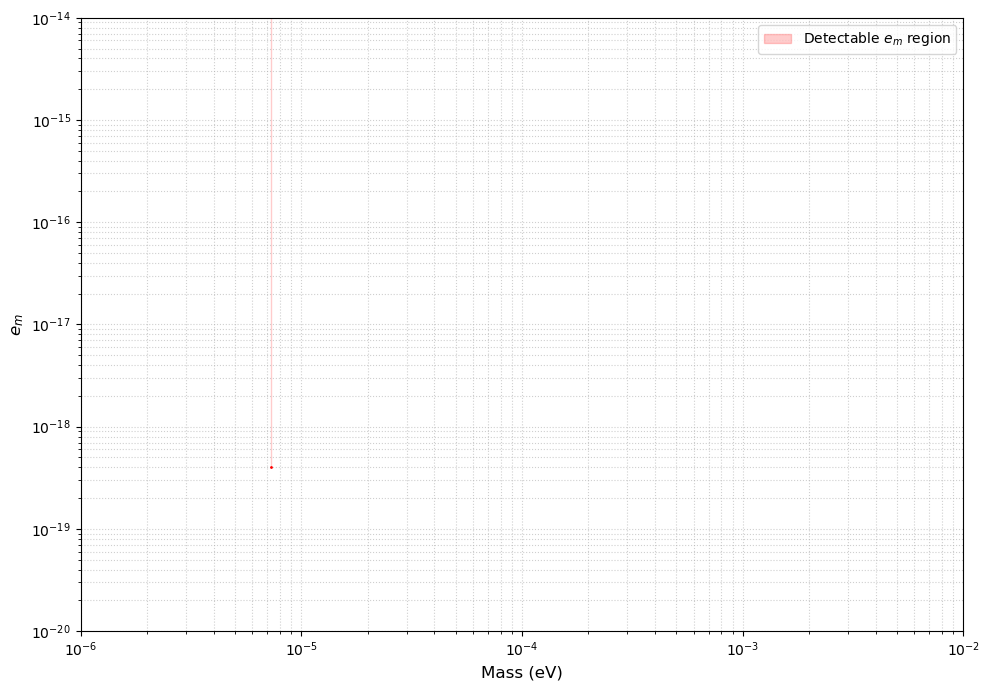

3.99687032272486e-19
7.321002907800102e-06
Each point represents a single mode


In [5]:
P_th = 1e-22
data_for_plot = []   
   
for row in resultsTE:
    n, p, q, omega_MHz, mass_eV, C, P_W, P_mc = row
    if P_mc > 0:   # only include modes with non-zero power factor
        e_min = (P_th / P_mc) ** 0.25
        data_for_plot.append((mass_eV, e_min, n, p, q))


masses = np.array([d[0] for d in data_for_plot])
e_m_required = np.array([d[1] for d in data_for_plot])


sorted_indices = np.argsort(masses)
masses_sorted = masses[sorted_indices]
e_m_sorted = e_m_required[sorted_indices]



fig, ax = plt.subplots(figsize=(10, 7))

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Mass (eV)', fontsize=12)
ax.set_ylabel(r'$e_m$', fontsize=12)

# Set axis limits (adjust as needed)
ax.set_xlim(1e-6, 1e-2)
ax.set_ylim(1e-20, 1e-14)


# Fill the area above the required e_m curve (detectable region)
ax.fill_between(masses_sorted, e_m_sorted, ax.get_ylim()[1], color='red', alpha=0.2, label='Detectable $e_m$ region')

# Overlay scatter points (smaller)
ax.scatter(masses_sorted, e_m_sorted, color='red', s=1, marker='o', zorder=5)

ax.legend(fontsize=10)
ax.grid(True, which='both', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

print(e_min)
print(mass_eV)
print(f'Each point represents a single mode')

In [6]:
import numpy as np

# Sort by mass
data_sorted = sorted(data_for_plot, key=lambda x: x[0])

# Define output filename
output_file = "my_modes.txt"

# Write to file with a header (similar to ADMX.txt)
with open(output_file, 'w') as f:
    f.write("# mass [eV]    e_m (dimensionless)\n")
    for mass, e_min, n, p, q in data_sorted:
        f.write(f"{mass:.6e}\t{e_min:.6e}\n")

print(f"Data written to {output_file}")

Data written to my_modes.txt


# TM MODES COMPUTATION

In [7]:
resultsTM = []

# Loop over all combinations
for n in range(0, n_max+1):
    for p in range(1, p_max+1):
        for q in range(0, q_max+1):
            mode_str = f"{n}{p}{q}"
            print(f"Computing TM mode {mode_str}...")  # optional progress indicator

            try:
                # Wavenumbers
                roots = jn_zeros(n, p)
                kc = roots[-1] / a
                kz = q * np.pi / d
                omega = c * np.sqrt(kc**2 + kz**2) # resonant angular frequency
                
                def J(r):
                    return  -r * omega

# First we define the radial component of the modes and their volum integral            
                def E_TM_z_rad (r):
                    return jv(n, kc * r) 

                def E_TM_z_rad_int (r):
                    return E_TM_z_rad(r) * r 

                def E_TM_z_rad_int2 (r):
                    return E_TM_z_rad(r)**2 * r

                def E_TM_r_rad (r):
                    if q == 0:
                        return 0.0
                    return - (kz / kc) * jvp(n, kc * r, 1)

                def E_TM_r_rad_int (r):
                    return E_TM_r_rad(r) * r

                def E_TM_r_rad_int2 (r):
                    return E_TM_r_rad(r)**2 * r

                def E_TM_theta_rad (r):
                    if n == 0 or q == 0:
                        return 0.0
                    return - (kz / kc**2 * r) * jv(n, kc * r) * n

                def E_TM_theta_rad_int (r):
                    return E_TM_theta_rad(r) * r

                def E_TM_theta_rad_int2 (r):
                    return E_TM_theta_rad(r)**2 * r

                def H_TM_r_rad (r):
                    if n == 0:
                        return 0.0
                    return -(omega * epsilon0 / kc**2) * (n / r) * jv(n, kc * r)

                def H_TM_r_rad_int (r):
                    return H_TM_r_rad(r) * r

                def H_TM_r_rad_int2 (r):
                    return H_TM_r_rad(r)**2 * r

                def H_TM_theta_rad (r):
                    return (omega * epsilon0 / kc) * jvp(n, kc * r, 1)

                def H_TM_theta_rad_int (r):
                    return H_TM_theta_rad(r) * r

                def H_TM_theta_rad_int2 (r):
                    return H_TM_theta_rad(r)**2 * r

                def Theta_comp_integrated(n):  # sin(nθ) or cos(nθ) 
                    if n == 0:
                        return 2*np.pi
                    return 0.0

                def Theta_comp_squared_integrated(n): # sin(nθ) or cos(nθ) squared
                    if n == 0:
                        return 2*np.pi
                    return np.pi

                def Z_comp_g1_integrated(q):  # cos(qpi/d)  g1: E_z, H_r, H_theta
                    if q == 0:
                        return d
                    return 0.0

                def Z_comp_g2_integrated(q):  # sin(qpi/d)  g2: E_r, E_theta 
                    if q == 0:
                        return 0.0
                    return d/(q*np.pi) * (1-(-1)**q)


                def Z_comp_g1_squared_integrated(q):  #  g1: E_z, H_r, H_theta
                    if q == 0:
                        return d
                    return d/2

                def Z_comp_g2_squared_integrated(q):  #  g2: E_z, H_r, H_theta
                    if q == 0:
                        return 0.0
                    return d/2

                int_E_z, _ = quad(E_TM_z_rad_int, 0, a)
                int_E_r, _ = quad(E_TM_r_rad_int, 0, a)
                int_E_theta, _ = quad(E_TM_theta_rad_int, 0, a)
                int_H_r, _ = quad(H_TM_r_rad_int, 0, a)
                int_H_theta, _ = quad(H_TM_theta_rad_int, 0, a)


                int_E_z2, _ = quad(E_TM_z_rad_int2, 0, a)
                int_E_r2, _ = quad(E_TM_r_rad_int2, 0, a)
                int_E_theta2, _ = quad(E_TM_theta_rad_int2, 0, a)
                int_H_r2, _ = quad(H_TM_r_rad_int2, 0, a)
                int_H_theta2, _ = quad(H_TM_theta_rad_int2, 0, a)

                def integrand_overlap(r):    
                        return E_TM_theta_rad(r) * J(r) * r

                overlap_integral, _ = quad(integrand_overlap, 0, a)

                E2_den = (int_E_z2 * Theta_comp_squared_integrated(n) * Z_comp_g1_squared_integrated(q) +
                        int_E_r2 * Theta_comp_squared_integrated(n) * Z_comp_g2_squared_integrated(q) +
                        int_E_theta2 * Theta_comp_squared_integrated(n) * Z_comp_g2_squared_integrated(q)) 

                overlap = (overlap_integral * Theta_comp_integrated(n) * Z_comp_g2_integrated(q) ) / (E2_den)
                
                form_factor = ((int_E_z * Theta_comp_integrated(n) * Z_comp_g1_integrated(q))**2
                                + (int_E_r * Theta_comp_integrated(n) * Z_comp_g2_integrated(q))**2 +
                               (int_E_theta * Theta_comp_integrated(n) * Z_comp_g2_integrated(q))**2) / (E2_den * V) if E2_den != 0 else np.nan

 # Store results with polarization info
                resultsTM.append((n, p, q, overlap, form_factor)) #E2_stored/V, H2_stored/V))

            except Exception as e:
                print(f"  Error for mode {mode_str}: {e}")
                resultsTM.append((n, p, q, np.nan, np.nan))

# Print table
print("\n" + "="*110)
print(f"{'n':<2} {'p':<2} {'q':<2} {'Overlap · V':<15} {'Form Factor':<15} {'∫|cE|² dV':<15} {'∫|cH|² dV':<15} {'Check (ε/μ) ratio':<15}")
print("="*110)
for n, p, q, ov, ff in resultsTM:
    #check = (epsilon0 * e2) / (mu0 * h2) if (h2 != 0 and not np.isnan(h2)) else np.nan
    print(f"{n:<2} {p:<2} {q:<2} {ov:<15.6e} {ff:<15.6e}")
print("="*110)

Computing TM mode 010...
Computing TM mode 011...

n  p  q  Overlap · V     Form Factor     ∫|cE|² dV       ∫|cH|² dV       Check (ε/μ) ratio
0  1  0  -0.000000e+00   6.916603e-01   
0  1  1  -0.000000e+00   5.279981e-02   
